# 01 · Data Cleaning, Outliers & EDA

Superstore dataset (9,994 order lines, Jan 2014 – Dec 2017). This notebook cleans the data, checks outliers with the IQR rule and explores what drives profit.
Dashboards (Power BI) and aggregations (SQL) live in other folders of this repo; here the focus is on the questions that need distributions and outliers.

**Notebook 02** builds the predictive models.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ASSETS = Path("../assets"); ASSETS.mkdir(exist_ok=True)

df = pd.read_csv("../data/superstore.csv", encoding="latin1")
df.shape

(9994, 21)

## 1. Inspect and clean

In [2]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print(f"Duplicate rows: {int(df.duplicated().sum())}")
print(f"Duplicate Row IDs: {int(df['Row ID'].duplicated().sum())}")
df.dtypes

Rows: 9,994  |  Columns: 21
Missing values: 0
Duplicate rows: 0
Duplicate Row IDs: 0


Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [3]:
# Dates are M/D/YYYY (same format the SQL script converts with style 101)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%m/%d/%Y")

print("Period:", df["Order Date"].min().date(), "->", df["Order Date"].max().date())
print("Orders shipped before they were placed:", int((df["Ship Date"] < df["Order Date"]).sum()))
print(f"Total sales : ${df['Sales'].sum():,.2f}")
print(f"Total profit: ${df['Profit'].sum():,.2f}")
print(f"Margin      : {df['Profit'].sum()/df['Sales'].sum():.2%}")
print("Distinct orders:", df["Order ID"].nunique())

Period: 2014-01-03 -> 2017-12-30
Orders shipped before they were placed: 0
Total sales : $2,297,200.86
Total profit: $286,397.02
Margin      : 12.47%
Distinct orders: 5009


The numbers match the SQL (`sql/import_data.sql`) and Power BI results: same period, same totals, same 5,009 orders. 
No missing values, no duplicates, no logic errors, so no rows are dropped.

## 2. Feature engineering (for EDA)

In [4]:
df["Year"]      = df["Order Date"].dt.year
df["Month"]     = df["Order Date"].dt.month
df["YearMonth"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df["Margin"]    = df["Profit"] / df["Sales"]          # EDA only, see note below
df["Discount Band"] = pd.cut(
    df["Discount"], bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=["0%", "1-20%", "21-40%", ">40%"])
df[["Order Date", "Year", "Month", "Margin", "Discount Band"]].head()

,Order Date,Year,Month,Margin,Discount Band
0,2016-11-08,2016,11,0.1600,0%
1,2016-11-08,2016,11,0.3000,0%
2,2016-06-12,2016,6,0.4700,0%
3,2015-10-11,2015,10,-0.4000,>40%
4,2015-10-11,2015,10,0.1125,1-20%


> **Note on leakage.** `Margin` (= Profit / Sales) is built from the target, so it is used **only for exploration**.
> It must never be a model feature. The original version of this project used `Profit Ratio` and `Profit_per_Unit` as inputs
> when predicting `Profit`, which inflated R². Notebook 02 shows the effect and fixes it.

## 3. Outliers with the IQR rule

In [5]:
def iqr_summary(data, col):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (data[col] < lo) | (data[col] > hi)
    return {"column": col, "lower": round(lo, 2), "upper": round(hi, 2),
            "n_low": int((data[col] < lo).sum()), "n_high": int((data[col] > hi).sum()),
            "n_outliers": int(mask.sum()), "pct": round(mask.mean() * 100, 1)}

outliers = pd.DataFrame([iqr_summary(df, c) for c in ["Sales", "Profit", "Quantity", "Discount"]])
outliers

,column,lower,upper,n_low,n_high,n_outliers,pct
0,Sales,-271.71,498.93,0,1167,1167,11.7
1,Profit,-39.72,70.82,604,1277,1881,18.8
2,Quantity,-2.50,9.50,0,170,170,1.7
3,Discount,-0.30,0.50,0,856,856,8.6


In [6]:
lo_p, hi_p = [iqr_summary(df, "Profit")[k] for k in ("lower", "upper")]
low  = df[df["Profit"] < lo_p]      # unusually large losses
high = df[df["Profit"] > hi_p]      # unusually large profits

print(f"Large-loss outliers  : {len(low):,}")
print(f"  share with discount > 20%      : {(low['Discount'] > 0.2).mean():.1%}")
print(f"  share of ALL lines with disc>20%: {(df['Discount'] > 0.2).mean():.1%}")
print(f"  total profit of these lines    : ${low['Profit'].sum():,.0f}")
print()
print(f"Large-profit outliers: {len(high):,}")
print("  by Category:", high['Category'].value_counts(normalize=True).round(3).to_dict())
print("  average discount:", round(high['Discount'].mean(), 3))
print()
print("Most extreme lines:")
df.loc[df["Profit"].abs().nlargest(5).index,
       ["Order ID", "Sub-Category", "Sales", "Discount", "Profit"]]

Large-loss outliers  : 604
  share with discount > 20%      : 81.6%
  share of ALL lines with disc>20%: 13.9%
  total profit of these lines    : $-140,327

Large-profit outliers: 1,277
  by Category: {'Office Supplies': 0.381, 'Technology': 0.376, 'Furniture': 0.244}
  average discount: 0.055

Most extreme lines:


,Order ID,Sub-Category,Sales,Discount,Profit
6826,CA-2016-118689,Copiers,17499.950,0.0,8399.9760
8153,CA-2017-140151,Copiers,13999.960,0.0,6719.9808
7772,CA-2016-108196,Machines,4499.985,0.7,-6599.9780
4190,CA-2017-166709,Copiers,10499.970,0.0,5039.9856
9039,CA-2016-117121,Binders,9892.740,0.0,4946.3700


**Reading the result.** IQR flags points in the tails, it does not say they are errors. Here they are real transactions:

- Of the 1,881 profit outliers, 604 are unusually **large losses** and 1,277 unusually **large profits**.
- Large losses are strongly tied to discounting: 81.6% of them carry a discount above 20%, although only 13.9% of all lines do.
- Large profits come with almost no discount (average 5.5%) and are spread across Office Supplies (38%) and Technology (38%), not concentrated in Technology.
- The single biggest profit and loss are both extreme tickets: a $17.5K Copiers sale (+$8.4K) and a 70%-discounted Machines sale (-$6.6K).

They are therefore **kept** in the data. Because they have a huge influence on squared-error metrics (R², RMSE), notebook 02 uses cross-validation and MAE next to R².

## 4. Distributions

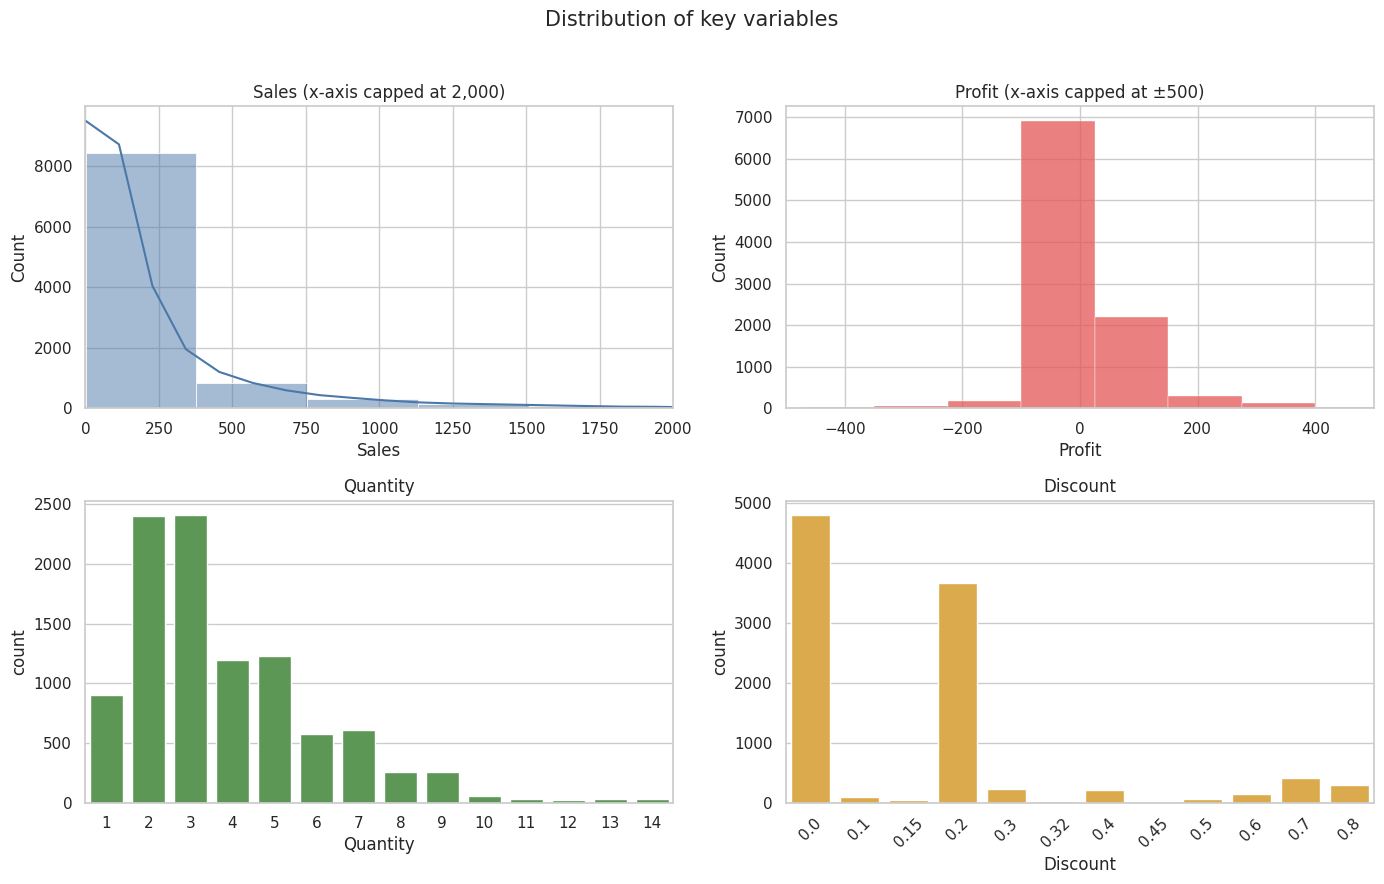

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribution of key variables", fontsize=15)
sns.histplot(df["Sales"], bins=60, kde=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_xlim(0, 2000); axes[0, 0].set_title("Sales (x-axis capped at 2,000)")
sns.histplot(df["Profit"], bins=120, ax=axes[0, 1], color="#E45756")
axes[0, 1].set_xlim(-500, 500); axes[0, 1].set_title("Profit (x-axis capped at ±500)")
sns.countplot(x="Quantity", data=df, ax=axes[1, 0], color="#54A24B"); axes[1, 0].set_title("Quantity")
sns.countplot(x="Discount", data=df, ax=axes[1, 1], color="#F2B134"); axes[1, 1].set_title("Discount")
axes[1, 1].tick_params(axis="x", rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(ASSETS / "01_distributions.png", dpi=130, bbox_inches="tight"); plt.show()

In [8]:
print(f"Median sales {df['Sales'].median():.1f} vs mean {df['Sales'].mean():.1f}  (right-skewed)")
print(f"Median profit {df['Profit'].median():.1f} vs mean {df['Profit'].mean():.1f}")
print(f"Loss-making lines: {(df['Profit'] < 0).sum():,} ({(df['Profit'] < 0).mean():.1%})")
print(f"Quantity 1-5: {(df['Quantity'] <= 5).mean():.0%} of lines")
print(f"Discount = 0: {(df['Discount'] == 0).mean():.0%} of lines")

Median sales 54.5 vs mean 229.9  (right-skewed)
Median profit 8.7 vs mean 28.7
Loss-making lines: 1,871 (18.7%)
Quantity 1-5: 81% of lines
Discount = 0: 48% of lines


## 5. Discount vs profit

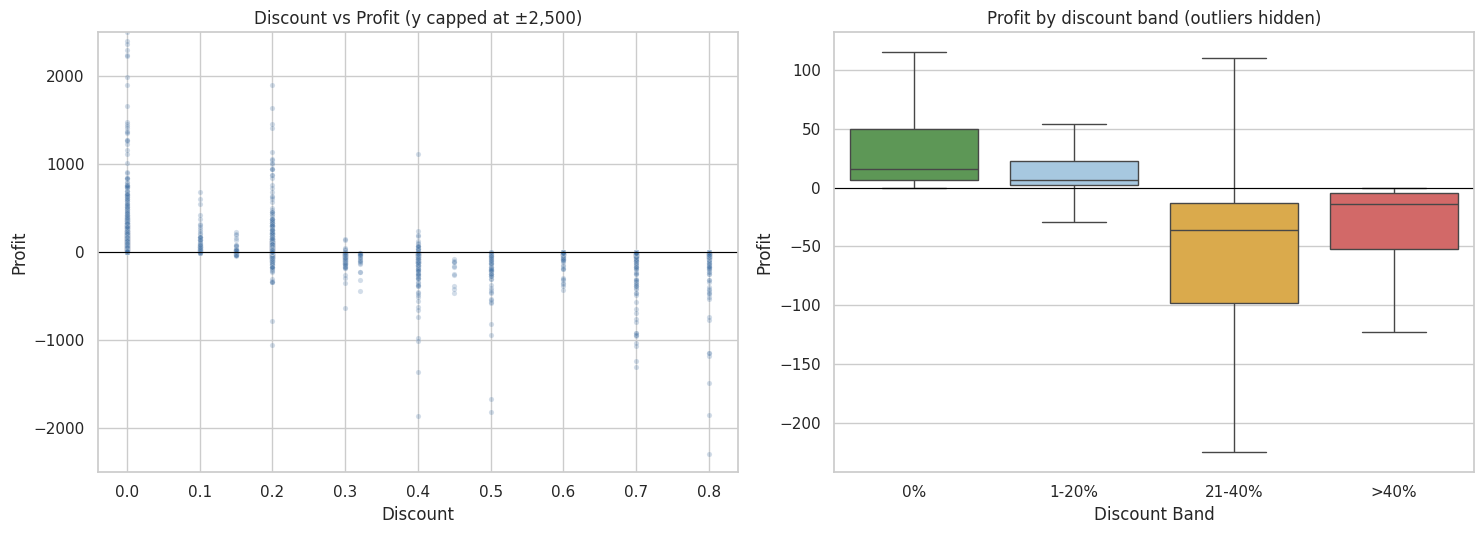

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(x="Discount", y="Profit", data=df, alpha=0.25, s=14, ax=axes[0], color="#4C78A8")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylim(-2500, 2500)
axes[0].set_title("Discount vs Profit (y capped at ±2,500)")

sns.boxplot(x="Discount Band", y="Profit", data=df, showfliers=False, ax=axes[1],
            palette=["#54A24B", "#9ECAE9", "#F2B134", "#E45756"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Profit by discount band (outliers hidden)")

plt.tight_layout()
plt.savefig(ASSETS / "02_discount_vs_profit.png", dpi=130, bbox_inches="tight"); plt.show()

In [10]:
band = (df.groupby("Discount Band", observed=True)
          .agg(lines=("Profit", "size"), sales=("Sales", "sum"), profit=("Profit", "sum"),
               loss_rate=("Profit", lambda s: (s < 0).mean())))
band["margin"] = band["profit"] / band["sales"]
band.style.format({"sales": "${:,.0f}", "profit": "${:,.0f}", "loss_rate": "{:.1%}", "margin": "{:.1%}"})

,lines,sales,profit,loss_rate,margin
Discount Band,,,,,
0%,4798,"$1,087,908","$320,988",0.0%,29.5%
1-20%,3803,"$846,522","$100,785",13.8%,11.9%
21-40%,460,"$234,138","$-35,817",90.2%,-15.3%
>40%,933,"$128,632","$-99,559",100.0%,-77.4%


Same picture as the SQL query Q6 and the Power BI *Profit by Discount Band* chart, now with the **loss rate** (share of lines with negative profit) added:
0% discount: no line loses money; 1-20%: 13.8% of lines lose; 21-40%: 90.2%; above 40%: 100%. Overall, **96.8% of lines with a discount above 20% are loss-making**.

## 6. Where is money lost? (sub-category, region)

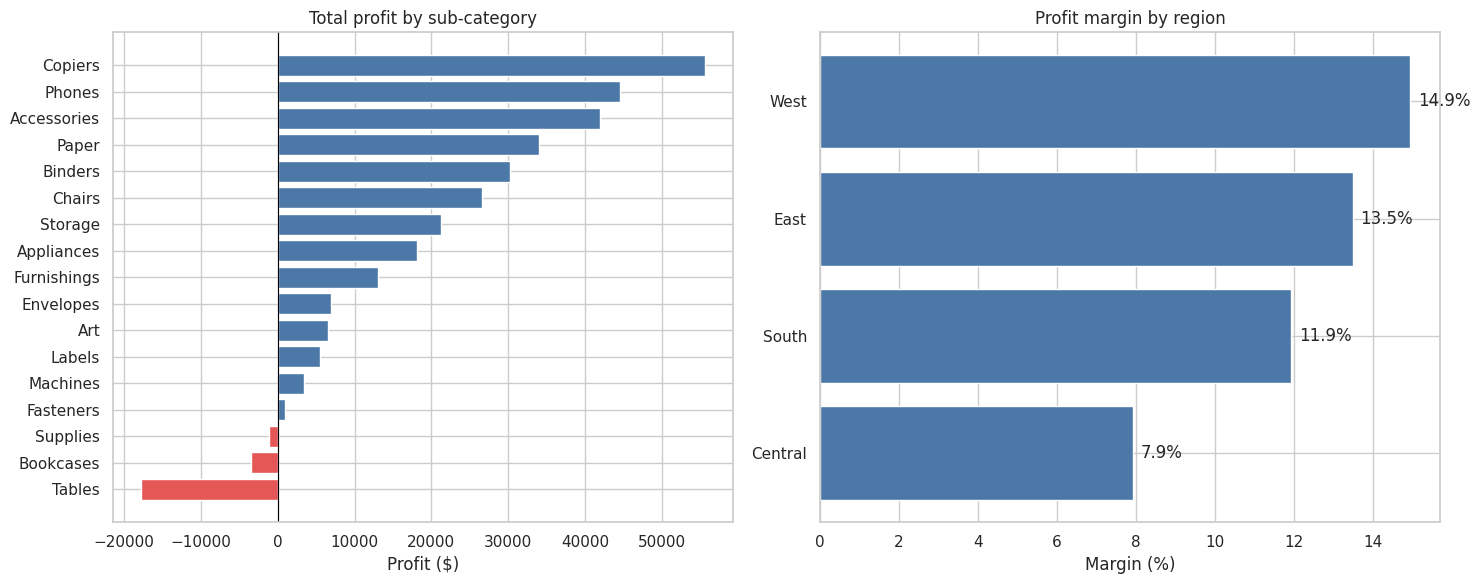

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sub = df.groupby("Sub-Category")["Profit"].sum().sort_values()
axes[0].barh(sub.index, sub.values, color=np.where(sub.values < 0, "#E45756", "#4C78A8"))
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Total profit by sub-category"); axes[0].set_xlabel("Profit ($)")

reg = df.groupby("Region").agg(sales=("Sales", "sum"), profit=("Profit", "sum"))
reg["margin"] = reg["profit"] / reg["sales"]
reg = reg.sort_values("margin")
axes[1].barh(reg.index, reg["margin"] * 100, color="#4C78A8")
for i, v in enumerate(reg["margin"] * 100):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center")
axes[1].set_title("Profit margin by region"); axes[1].set_xlabel("Margin (%)")

plt.tight_layout()
plt.savefig(ASSETS / "03_subcategory_region.png", dpi=130, bbox_inches="tight"); plt.show()

In [12]:
sub_df = df.groupby("Sub-Category").agg(sales=("Sales", "sum"), profit=("Profit", "sum"),
                                         avg_discount=("Discount", "mean")).sort_values("profit")
sub_df.head(4).style.format({"sales": "${:,.0f}", "profit": "${:,.0f}", "avg_discount": "{:.1%}"})

,sales,profit,avg_discount
Sub-Category,,,
Tables,"$206,966","$-17,725",26.1%
Bookcases,"$114,880","$-3,473",21.1%
Supplies,"$46,674","$-1,189",7.7%
Fasteners,"$3,024",$950,8.2%


Tables, Bookcases and Supplies are the only sub-categories with negative total profit. Tables (average discount 26%) and Bookcases (21%) discount much more than the 15% dataset average, which links them to the discount finding. 
Supplies (7.7% average discount) loses money for a different reason, so discounting alone does not explain every loss.

## 7. Monthly trend (Year-Month)

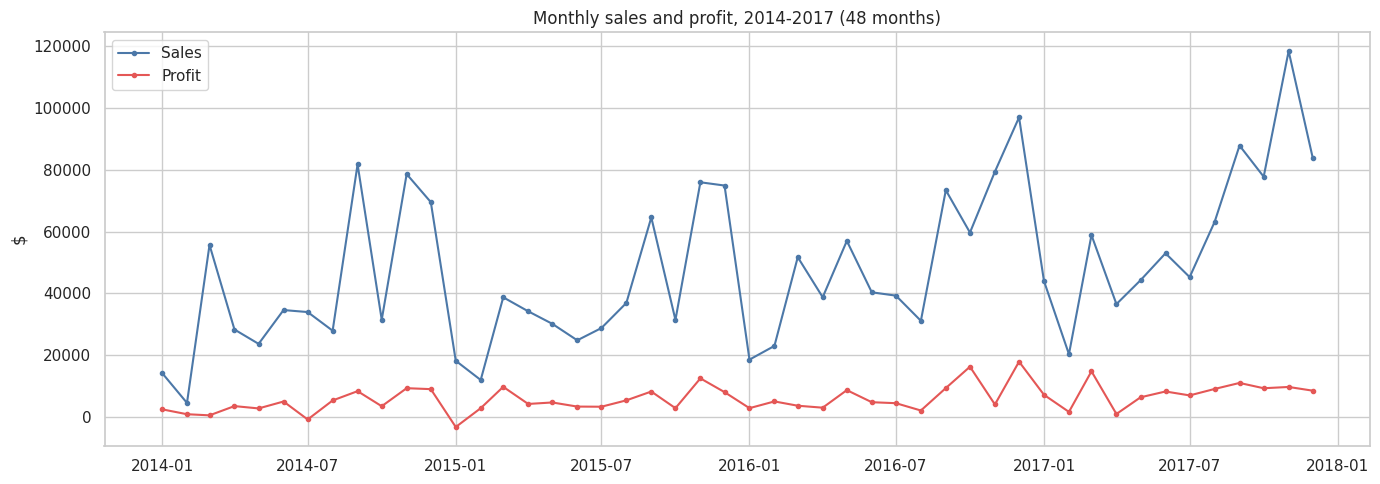

In [13]:
monthly = df.groupby("YearMonth").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly["Sales"], marker="o", ms=3, label="Sales", color="#4C78A8")
ax.plot(monthly.index, monthly["Profit"], marker="o", ms=3, label="Profit", color="#E45756")
ax.set_title("Monthly sales and profit, 2014-2017 (48 months)")
ax.set_ylabel("$"); ax.legend()
plt.tight_layout()
plt.savefig(ASSETS / "04_monthly_trend.png", dpi=130, bbox_inches="tight"); plt.show()

In [14]:
q = df.groupby(df["Order Date"].dt.quarter)["Sales"].sum()
m = df.groupby("Month")["Sales"].sum()
print("Share of sales by quarter:", (q / q.sum()).round(3).to_dict())
print(f"Sep + Nov + Dec share of sales: {m.loc[[9, 11, 12]].sum() / m.sum():.1%}")
yearly = df.groupby("Year").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
yearly["Margin"] = yearly["Profit"] / yearly["Sales"]
yearly["Sales YoY"] = yearly["Sales"].pct_change()
yearly.style.format({"Sales": "${:,.0f}", "Profit": "${:,.0f}", "Margin": "{:.1%}", "Sales YoY": "{:.1%}"})

Share of sales by quarter: {1: 0.157, 2: 0.194, 3: 0.267, 4: 0.382}
Sep + Nov + Dec share of sales: 42.9%


,Sales,Profit,Margin,Sales YoY
Year,,,,
2014,"$484,247","$49,544",10.2%,nan%
2015,"$470,533","$61,619",13.1%,-2.8%
2016,"$609,206","$81,795",13.4%,29.5%
2017,"$733,215","$93,439",12.7%,20.4%


Sales are strongly seasonal: Q4 brings 38% of revenue and September, November and December together 43%, consistent with the Power BI dashboard.
Sales fell slightly in 2015 (-2.8%), then grew 29.5% in 2016 and 20.4% in 2017, while margin stayed around 13%.

## 8. Summary

- Data is clean: 9,994 lines, no missing values or duplicates; totals match the SQL and Power BI work.
- Profit and Sales are heavy-tailed. IQR outliers are real transactions and are kept.
- **Discount is the main lever on profit.** 96.8% of lines above a 20% discount are loss-making.
- Three sub-categories (Tables, Bookcases, Supplies) lose money overall.
- Next: notebook 02 tests how well profit and loss-making lines can be predicted, without target leakage.